# Critic-Actor / Evaluator-Optimizer -- Code Generation with Test-Execution Feedback

## Problem card

- **User/trigger:** a user gives a function spec (signature + plain-English behavior)
  plus a fixed set of test cases.
- **Inputs:** the spec, and a list of executable test assertions the final function must
  satisfy.
- **Output:** a Python function implementation that passes every test, or, if the round
  budget runs out first, the best attempt plus an honest report of which tests still
  fail and why.
- **Success criteria:** every test either passes for a real, verifiable reason (the code
  was actually executed against it) or the notebook says clearly that it didn't pass --
  never a fabricated "looks correct" claim standing in for execution.
- **Topology:** **critic-actor / evaluator-optimizer** -- three distinct LLM agents
  (`actor`, `critic`, `reviser`), each with its **own system message and its own job**,
  wired around one deterministic, non-LLM step (`run_tests`) that actually executes the
  code. The loop repeats write -> test -> diagnose -> repair -> test again, up to a
  fixed round budget.

## Why this pattern (and why it needs three agents, not one)

A single "write correct code" agent has no way to know whether its first attempt is
actually correct -- it can only guess, because it never sees real execution feedback.
Critic-actor/evaluator-optimizer fixes that by putting a **real, deterministic
execution step** in the loop and giving the model that step's real output back, instead
of asking the model to grade its own work from memory.

This notebook goes one step further than a two-role "actor + critic" loop and uses
**three separate agents**, because "diagnose why something is broken" and "rewrite code
to fix it" are genuinely different skills with different failure modes:

- A **critic** that also has to rewrite the code tends to jump straight to a fix without
  clearly stating *why* the current code is wrong -- which makes its own revision harder
  to trust and impossible to audit separately from the diagnosis.
- A **reviser** that has to both diagnose and fix from scratch every round re-derives the
  same root cause repeatedly instead of building on a clean diagnosis, and is more prone
  to rewriting working code it didn't need to touch.

Splitting them means the critic's diagnosis is a **readable, inspectable artifact on its
own** (you can print it and understand exactly what's wrong), and the reviser's job
becomes narrow and mechanical: apply *this specific* diagnosis, touch nothing else.

## The four steps (three agents + one deterministic tool)

| # | Step | Kind | System message role | Reads | Writes |
|---|---|---|---|---|---|
| 1 | `actor` | LLM agent | Write a first-attempt implementation from the spec alone -- no test results exist yet | `spec` | `code` |
| 2 | `run_tests` | **Deterministic, no LLM** | Actually execute `code` against every test assertion | `code`, `tests` | `test_results` |
| 3 | `critic` | LLM agent | Diagnose *why* any failing tests failed -- root cause, not a fix | `spec`, `code`, `test_results` | `critique` |
| 4 | `reviser` | LLM agent | Apply the critic's diagnosis as a minimal, targeted fix -- do not rewrite passing behavior | `spec`, `code`, `critique` | `code` (overwritten) |

Steps 2-4 repeat (`run_tests` again after `reviser`) until every test passes or a fixed
round budget (`MAX_ROUNDS = 3`) is exhausted. Critically, **`run_tests` is not an LLM
call at all** -- it is real Python `exec()` against the test assertions. This is what
makes the critic's diagnosis execution-grounded instead of the model guessing at its own
correctness.


In [1]:
import os
import time
import traceback
import warnings
import logging
from typing import TypedDict
from dotenv import load_dotenv, find_dotenv

warnings.filterwarnings("ignore")
logging.getLogger("chromadb").setLevel(logging.ERROR)

load_dotenv(find_dotenv(usecwd=True))
OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END

llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0.2)

MAX_ROUNDS = 3

print(f"Model: {OPENAI_MODEL}, max revision rounds: {MAX_ROUNDS}")


Model: gpt-4o-mini, max revision rounds: 3


## The task: `parse_duration`

A deliberately fiddly string-parsing spec -- the kind of function that's easy to get
*mostly* right on a first pass and easy to get subtly wrong on an edge case (unit
ordering, a missing unit, a value with only seconds). This is chosen specifically so the
critic-actor loop has real work to do, not a rigged failure.

**Spec given to the actor:**

> Write a Python function `parse_duration(s: str) -> int` that parses a duration string
> like `"1h30m"`, `"45m"`, `"2h"`, or `"90s"` into a total number of seconds (an int).
> The string may contain any combination of an `h` (hours), `m` (minutes), and `s`
> (seconds) component, each optional, always in that order when present, with no spaces.
> Raise `ValueError` if the string is empty or contains no valid unit.


In [2]:
SPEC = (
    "Write a Python function `parse_duration(s: str) -> int` that parses a duration "
    "string like '1h30m', '45m', '2h', or '90s' into a total number of seconds (an "
    "int). The string may contain any combination of an 'h' (hours), 'm' (minutes), "
    "and 's' (seconds) component, each optional, always in that order when present, "
    "with no spaces. Raise ValueError if the string is empty or contains no valid unit."
)

# Each test is a real, executable Python assertion -- run_tests below actually
# exec()s these against the candidate implementation. No test is graded by an LLM.
TESTS = [
    "parse_duration('45m') == 45 * 60",
    "parse_duration('2h') == 2 * 3600",
    "parse_duration('90s') == 90",
    "parse_duration('1h30m') == 1 * 3600 + 30 * 60",
    "parse_duration('1h5m10s') == 3600 + 5 * 60 + 10",
    "parse_duration('0h30m') == 30 * 60",
    "parse_duration('100s') == 100",
    "_raises_value_error(parse_duration, '')",
    "_raises_value_error(parse_duration, 'abc')",
]

print(f"{len(TESTS)} real executable test assertions defined.")


9 real executable test assertions defined.


## State

`code` is overwritten each round (only the latest attempt matters going forward), while
`history` keeps every round's code + test results + critique -- so the full loop is
auditable at the end, not just the final outcome.


In [3]:
class RepairState(TypedDict, total=False):
    spec: str
    tests: list[str]
    code: str
    test_results: list[dict]
    critique: str
    round: int
    all_passed: bool
    history: list[dict]


## Agent 1: `actor` -- first-attempt implementation

System message: write code from the spec alone. It has never seen a test result and
never will see one directly -- by the time tests fail, the *critic* (not the actor)
is the one who reads the failures, precisely so the actor's system message stays
narrowly about "translate spec to code," never blurring into "guess what broke."


In [4]:
ACTOR_SYSTEM_PROMPT = (
    "You are a Python implementation agent. Given a function spec, write a single, "
    "complete Python function that implements it exactly as described. Output ONLY "
    "the function definition as valid Python code -- no markdown fences, no "
    "explanation, no example usage, no test calls. Assume nothing about the input "
    "beyond what the spec states."
)


def actor_node(state: RepairState) -> dict:
    messages = [
        SystemMessage(content=ACTOR_SYSTEM_PROMPT),
        HumanMessage(content=f"Spec:\n{state['spec']}"),
    ]
    response = llm.invoke(messages)
    return {"code": _strip_code_fence(response.content), "round": 1}


In [5]:
def _strip_code_fence(text: str) -> str:
    text = text.strip()
    if text.startswith("```"):
        lines = text.splitlines()
        lines = lines[1:] if lines[0].startswith("```") else lines
        if lines and lines[-1].strip().startswith("```"):
            lines = lines[:-1]
        text = "\n".join(lines)
    return text.strip()


## Step 2: `run_tests` -- deterministic execution, no LLM involved

This is the load-bearing step that makes the whole pattern trustworthy: the candidate
`code` is actually `exec()`'d and every test assertion is actually evaluated against it,
in an isolated namespace. A test's `passed` field is a real Python truth value, not a
model's opinion.


In [6]:
def _raises_value_error(fn, arg) -> bool:
    try:
        fn(arg)
        return False
    except ValueError:
        return True


def run_tests_node(state: RepairState) -> dict:
    namespace = {"_raises_value_error": _raises_value_error}
    results = []
    try:
        exec(state["code"], namespace)
    except Exception as exc:
        # The code itself doesn't even parse/run -- every test fails with the same cause.
        for test in state["tests"]:
            results.append({
                "test": test, "passed": False,
                "error": f"code failed to define/execute: {exc!r}",
            })
        all_passed = False
        return _record_round(state, results, all_passed)

    for test in state["tests"]:
        try:
            passed = bool(eval(test, namespace))
            error = None if passed else "assertion evaluated to False"
        except Exception as exc:
            passed = False
            error = f"{type(exc).__name__}: {exc}"
        results.append({"test": test, "passed": passed, "error": error})

    all_passed = all(r["passed"] for r in results)
    return _record_round(state, results, all_passed)


def _record_round(state: RepairState, results: list[dict], all_passed: bool) -> dict:
    history = list(state.get("history", []))
    history.append({
        "round": state.get("round", 1), "code": state["code"],
        "test_results": results, "all_passed": all_passed,
    })
    return {"test_results": results, "all_passed": all_passed, "history": history}


## Agent 2: `critic` -- diagnose, do not fix

System message: explain *why* each failing test fails, in terms of the code's actual
logic -- explicitly forbidden from writing a fix. This keeps the diagnosis honest and
inspectable on its own, and stops the critic from silently prescribing one specific fix
that the reviser then just copies without understanding.


In [7]:
CRITIC_SYSTEM_PROMPT = (
    "You are a code-review critic agent. You are given a function spec, a candidate "
    "implementation, and the REAL results of running that code against a set of test "
    "assertions (which ones passed, which failed, and the exact error for each "
    "failure). Your only job is diagnosis: for each FAILING test, explain precisely "
    "why the current code produces the wrong behavior for that case -- trace through "
    "the actual logic, do not guess. Do NOT write corrected code and do NOT propose a "
    "specific replacement implementation -- another agent handles the fix. If every "
    "test passed, say so in one sentence and nothing else."
)


def critic_node(state: RepairState) -> dict:
    results_text = "\n".join(
        f"- {r['test']} -> {'PASSED' if r['passed'] else 'FAILED'}"
        + (f" ({r['error']})" if r["error"] else "")
        for r in state["test_results"]
    )
    messages = [
        SystemMessage(content=CRITIC_SYSTEM_PROMPT),
        HumanMessage(
            content=(
                f"Spec:\n{state['spec']}\n\n"
                f"Candidate code:\n{state['code']}\n\n"
                f"Real test execution results:\n{results_text}"
            )
        ),
    ]
    response = llm.invoke(messages)
    return {"critique": response.content}


## Agent 3: `reviser` -- apply the diagnosis, minimally

System message: fix exactly what the critic identified, and explicitly avoid rewriting
behavior that already passed. This is the "optimizer" half of evaluator-optimizer --
narrow, targeted, and accountable to the critic's diagnosis rather than free to redesign
the function from scratch.


In [8]:
REVISER_SYSTEM_PROMPT = (
    "You are a code-repair agent. You are given a function spec, the current code, "
    "and a critic's diagnosis of exactly why specific tests are failing. Apply the "
    "MINIMAL change needed to fix the diagnosed problems -- do not restructure or "
    "rewrite parts of the function the diagnosis did not flag, and do not change "
    "behavior for cases the diagnosis says are already correct. Output ONLY the "
    "corrected function definition as valid Python code -- no markdown fences, no "
    "explanation."
)


def reviser_node(state: RepairState) -> dict:
    messages = [
        SystemMessage(content=REVISER_SYSTEM_PROMPT),
        HumanMessage(
            content=(
                f"Spec:\n{state['spec']}\n\n"
                f"Current code:\n{state['code']}\n\n"
                f"Critic's diagnosis:\n{state['critique']}"
            )
        ),
    ]
    response = llm.invoke(messages)
    return {"code": _strip_code_fence(response.content), "round": state.get("round", 1) + 1}


## Wiring the loop

`START -> actor -> run_tests`, then a conditional edge: if every test passed, or the
round budget is exhausted, go to `END`; otherwise go to `critic -> reviser ->
run_tests`, repeating. Note the loop re-enters `run_tests` after every `reviser` call --
the reviser's fix is never trusted without being executed again for real.


In [9]:
def route_after_tests(state: RepairState):
    if state["all_passed"]:
        return "END"
    if state.get("round", 1) > MAX_ROUNDS:
        return "END"
    return "critic"


builder = StateGraph(RepairState)
builder.add_node("actor", actor_node)
builder.add_node("run_tests", run_tests_node)
builder.add_node("critic", critic_node)
builder.add_node("reviser", reviser_node)

builder.add_edge(START, "actor")
builder.add_edge("actor", "run_tests")
builder.add_conditional_edges("run_tests", route_after_tests, {"critic": "critic", "END": END})
builder.add_edge("critic", "reviser")
builder.add_edge("reviser", "run_tests")

repair_pipeline = builder.compile()
print("Critic-actor / evaluator-optimizer repair loop compiled.")


Critic-actor / evaluator-optimizer repair loop compiled.


### Graph diagram

```mermaid
graph TD
    START([START]) --> actor["actor\n(system: write from spec, no test results seen)"]
    actor --> run_tests{{"run_tests\n(deterministic exec -- NOT an LLM call)"}}
    run_tests -->|all passed OR round budget exhausted| END([END])
    run_tests -->|failures remain, budget left| critic["critic\n(system: diagnose only, no fixing)"]
    critic --> reviser["reviser\n(system: minimal targeted fix only)"]
    reviser --> run_tests
```

Three distinct boxes, three distinct system messages, one shared deterministic checkpoint
(`run_tests`) that every revision must pass back through before it's trusted. That
diamond shape -- LLM, then real execution, then a *different* LLM that only diagnoses,
then a *third* LLM that only repairs -- is the structural signature of critic-actor /
evaluator-optimizer, and is why this is not just "an agent looping until it feels
done."


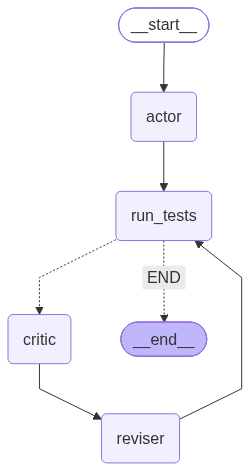

In [10]:
from IPython.display import Image, display

try:
    display(Image(repair_pipeline.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(Diagram render skipped -- {e}. See the Mermaid block above for the same graph.)")


## Running the loop end to end

Every round's code, real test results, and (when applicable) the critic's diagnosis are
printed in full -- this is the entire point of the pattern: nothing here is a summary or
a claim, it is the real transcript of what the actor wrote, what actually happened when
it ran, and what the critic and reviser did about it.


In [11]:
t0 = time.time()
final_state = repair_pipeline.invoke({"spec": SPEC, "tests": TESTS})
elapsed = time.time() - t0

print(f"Loop finished in {elapsed:.2f}s across {len(final_state['history'])} test-execution round(s).")
print(f"All tests passing at the end: {final_state['all_passed']}")


Loop finished in 4.10s across 1 test-execution round(s).
All tests passing at the end: True


In [12]:
for entry in final_state["history"]:
    n_passed = sum(1 for r in entry["test_results"] if r["passed"])
    n_total = len(entry["test_results"])
    print("=" * 70)
    print(f"ROUND {entry['round']} -- {n_passed}/{n_total} tests passed")
    print("=" * 70)
    print(entry["code"])
    print("\n--- real test execution results ---")
    for r in entry["test_results"]:
        status = "PASS" if r["passed"] else "FAIL"
        line = f"  [{status}] {r['test']}"
        if r["error"]:
            line += f"  <- {r['error']}"
        print(line)
    print()


ROUND 1 -- 9/9 tests passed
def parse_duration(s: str) -> int:
    if not s:
        raise ValueError("Input string is empty")
    
    total_seconds = 0
    hours = minutes = seconds = 0
    
    i = 0
    while i < len(s):
        if s[i].isdigit():
            start = i
            while i < len(s) and s[i].isdigit():
                i += 1
            num = int(s[start:i])
            if i < len(s):
                if s[i] == 'h':
                    total_seconds += num * 3600
                elif s[i] == 'm':
                    total_seconds += num * 60
                elif s[i] == 's':
                    total_seconds += num
                else:
                    raise ValueError("Invalid unit found")
                i += 1
            else:
                raise ValueError("Input string contains no valid unit")
        else:
            raise ValueError("Input string contains no valid unit")
    
    if total_seconds == 0:
        raise ValueError("Input string contains no

In [13]:
if not final_state["all_passed"]:
    print("Final critic diagnosis (most recent round):")
    print(final_state.get("critique", "(no critique recorded)"))
else:
    print("Every test passed -- no outstanding critique.")


Every test passed -- no outstanding critique.


**Expected output**: read the real per-round transcript above, not a fixed assumption.
Two honest possible outcomes, and both are legitimate results of running this pattern
for real:

- **The actor got everything right on round 1.** `parse_duration` is a plausible enough
  spec that `gpt-4o-mini` sometimes nails every edge case first try -- if so, the loop
  correctly exits after `run_tests` with zero critic/reviser calls spent, which is the
  *efficient* success path this pattern is supposed to take when there's nothing to fix.
  This is a genuine null result, not a failure of the notebook.
- **The actor missed at least one edge case**, most plausibly `'100s'` (does the parser
  correctly treat this as 100 seconds rather than misparsing the two-digit value?) or
  the empty/invalid-string `ValueError` cases (easy to forget entirely on a first pass).
  If so, you'll see the critic's real diagnosis and the reviser's real targeted fix, and
  a second `run_tests` round showing whether that specific fix actually worked -- the
  core value of the pattern, made visible.

Either way, the number reported above (`all_passed`, and how many rounds it took) is the
real, measured outcome of this run -- not asserted, not guaranteed in advance.

## Common mistakes

- **Letting the critic also rewrite the code.** If `critic_node`'s prompt allowed it to
  output a fix, you'd lose the clean, inspectable diagnosis-as-artifact this notebook
  relies on, and the reviser's job would collapse into "copy what the critic already
  wrote" instead of independently reasoning about a minimal fix.
- **Grading tests with an LLM instead of executing them.** If `run_tests_node` asked the
  model "does this code look correct?" instead of actually calling `exec()`/`eval()`,
  the entire loop would be ungrounded -- the critic would be diagnosing failures that
  might not even be real, and "all tests passed" would mean nothing more than "the model
  said so."
- **No round budget.** Without `MAX_ROUNDS`, a spec the model genuinely cannot satisfy
  (an ambiguous or contradictory requirement) would loop forever. The budget converts an
  open-ended failure into a bounded, honestly-reported one (`all_passed=False` after N
  rounds, with the last real diagnosis attached) instead of an infinite retry.
- **Reviser rewriting passing behavior.** Because `reviser_node`'s system message is
  scoped to "minimal change... do not change behavior for cases already correct," a
  round-2 fix that accidentally breaks a round-1-passing test is a genuine regression
  the notebook would actually surface (via `run_tests` re-executing all tests, not just
  the previously-failing ones) -- worth checking for explicitly in the round-by-round
  transcript above.
- **Confusing this with plan-execute-replan.** That pattern (notebook 04) revises a
  *plan* based on execution outcomes of *steps within* the plan. This pattern revises an
  *artifact* (code) based on execution outcomes of *tests against the whole artifact* --
  there's no multi-step plan here, just one artifact scored as a whole each round.

## Explain like I'm 12

Imagine you're building a toy car for a school competition with three rules it has to
pass (goes straight, doesn't fall apart, fits in the box). You build it (that's the
**actor**). Then you actually run it through all three tests for real -- you don't just
look at it and guess (that's **run_tests**, and it's not even a person, it's just the
rules themselves being checked). If it fails a rule, you don't get to fix it yourself
right away -- first a friend who's really good at spotting *why* things break looks at
exactly which rule failed and explains what's wrong, without touching the car (that's
the **critic**). Only then does a different friend, who's really good at fixing things
precisely, make the smallest change needed to fix just that problem, without messing up
the parts that already worked (that's the **reviser**). Then you run all three rules
again for real, because "I fixed it" isn't good enough -- you have to prove it.

## Explain for interview

"This is critic-actor / evaluator-optimizer with three distinct agents around one
deterministic checkpoint: an actor writes a first attempt, a non-LLM step actually
executes it against real tests, a critic diagnoses *why* any failures happened without
proposing a fix, and a reviser applies a minimal, targeted fix based on that diagnosis
-- which then goes back through the same real execution step before being trusted. The
three-way split matters because diagnosis and repair are different skills: a critic that
also fixes tends to skip explaining its reasoning, and a reviser that also diagnoses
tends to re-derive the same root cause every round instead of building on a clean one.
The pattern's whole value depends on `run_tests` being real execution, not an LLM's
opinion -- otherwise the loop just launders a guess through more LLM calls without ever
grounding it in truth."

## Glossary

- **Actor** -- the agent that produces the first-attempt artifact from the spec alone,
  with no test-result feedback yet.
- **Evaluator / critic** -- the agent (or deterministic step) that scores or diagnoses
  the artifact against ground truth. Split here into two parts: `run_tests` (real
  execution, the actual evaluation) and `critic` (turns raw execution results into a
  readable diagnosis).
- **Optimizer / reviser** -- the agent that revises the artifact based on the
  evaluator's/critic's findings, ideally with a minimal, targeted change rather than a
  full rewrite.
- **Execution-grounded feedback** -- feedback derived from actually running the
  artifact (real `exec()`/`eval()` results here), as opposed to an LLM's text opinion
  about whether the artifact looks correct.
- **Round budget** (`MAX_ROUNDS`) -- the fixed cap on revise-and-recheck cycles that
  converts an unbounded retry loop into a bounded, honestly-reported outcome.

## Checkpoint questions

1. **Q: Why does `run_tests_node` contain no LLM call at all?**
   A: So the pass/fail signal the critic reasons about is real Python execution truth,
   not a model's guess about whether code looks correct -- this is what makes the
   critic's diagnosis and the reviser's fix trustworthy rather than circular.

2. **Q: Why are `critic` and `reviser` two separate agents instead of one "critique and
   fix" agent?**
   A: Diagnosis and repair are different skills -- a combined agent tends to jump to a
   fix without a clear, inspectable explanation of *why* the code was wrong, and loses
   the ability to audit the diagnosis independently of the fix that was applied.

3. **Q: What happens if the reviser's fix breaks a test that was previously passing?**
   A: `run_tests` re-executes *every* test each round, not just the previously-failing
   ones, so a regression would show up directly in that round's transcript as a newly
   failing test -- the loop doesn't just check the tests it was trying to fix.

4. **Q: Why does the graph route back to `run_tests` after `reviser`, instead of trusting
   the reviser's fix directly?**
   A: A model claiming to have fixed the code is not the same as the code actually being
   fixed -- every revision has to pass back through real execution before `all_passed`
   can become `True`.

5. **Q: What does `MAX_ROUNDS` protect against, and what does the notebook do if it's
   reached without all tests passing?**
   A: It protects against looping forever on a spec the model can't actually satisfy;
   when the budget runs out, `route_after_tests` sends the graph to `END` with
   `all_passed=False` and the last real critique still attached, so the failure is
   reported honestly rather than retried indefinitely.

6. **Q: How is this different from the plan-execute-replan pattern in notebook 04?**
   A: Plan-execute-replan revises a multi-step *plan* based on how individual steps
   played out; this pattern revises one *artifact* (the whole function) based on how it
   scores against a fixed set of tests as a whole -- there's no multi-step plan being
   tracked here.
